# Creating a small dataset for Binary Classification 

In [2]:
import numpy as np 
np.random.seed(42)

In [4]:
# 1000 samples , each with 2 features
x = np.random.randn(1000,2)

In [6]:
# Rule : if x1 + x2 > 0 ---> class 1 
# else class 0

In [8]:
y = (x[:,0] + x [:,1] > 0). astype(int)

In [9]:
print(x.shape)
print(y.shape)
print(x[:5])
print(y[:5])

(1000, 2)
(1000,)
[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]
 [-0.46947439  0.54256004]]
[1 1 0 1 1]


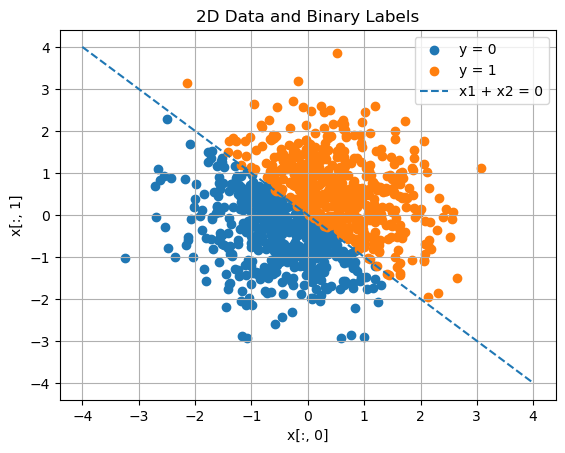

In [11]:
import matplotlib.pyplot as plt


# Plot x[:, 0] vs x[:, 1]
plt.scatter(x[y == 0, 0], x[y == 0, 1],
            label="y = 0", marker="o")

plt.scatter(x[y == 1, 0], x[y == 1, 1],
            label="y = 1", marker="o")

# Decision boundary: x1 + x2 = 0
x1 = np.linspace(-4, 4, 100)
x2 = -x1

plt.plot(x1, x2, linestyle="--", label="x1 + x2 = 0")

plt.xlabel("x[:, 0]")
plt.ylabel("x[:, 1]")
plt.title("2D Data and Binary Labels")
plt.legend()
plt.grid(True)
plt.show()

# Test Train Split

In [15]:
num_samples = x.shape[0]
indices = np.arange(num_samples)
np.random.shuffle(indices)

train_size = int(0.8 * num_samples)


train_indices = indices[:train_size]
test_indices = test_indices = indices[train_size:]

x_train = x[train_indices]
y_train = y[train_indices]

x_test = x[test_indices]
y_test = y[test_indices]



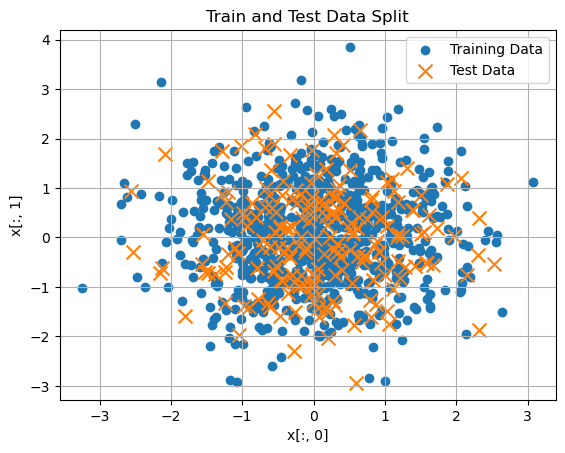

In [16]:
# Plot training and test data
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    label="Training Data",
    marker="o"
)

plt.scatter(
    x_test[:, 0],
    x_test[:, 1],
    label="Test Data",
    marker="x",
    s=100
)

plt.xlabel("x[:, 0]")
plt.ylabel("x[:, 1]")
plt.title("Train and Test Data Split")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(800, 2)
(800,)
(200, 2)
(200,)


# Accuracy Function 

In [18]:
def accuracy(y_true,y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

In [20]:
y_true = np.array([0,1,1,0,1])
y_pred = np.array([0,1,0,0,1])

acc = accuracy(y_true,y_pred)
print(acc)

0.8


In [22]:
y = y.reshape(-1,1)
y.shape

(1000, 1)

# Intialize parameters 

In [23]:
input_dim = 2
W = np.random.randn(input_dim,1)*0.01
b = 0.0
learning_rate = 0.1
epochs = 1000

In [27]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [28]:
for epoch in range(epochs):
    # Forward pass
    logits = x @ W + b
    y_pred = sigmoid(logits)
    loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y)*np.log(1-y_pred +1e-8))
    # Gradients
    error = y_pred - y
    dW = x.T @ error / (x.shape[0])
    db = np.mean(error)
    # Parameter update
    W = W - learning_rate * dW
    b = b - learning_rate *db
    if epoch % 100 ==0 :
        predictions = (y_pred >= 0.5).astype(int)
        acc = np.mean(predictions == y)
        print(f"epoch : {epoch}, Loss : {loss:.4f}, Accuracy: {acc:.4f}")
print("Final Weights:", W)
print("Final Bias :", b)

epoch : 0, Loss : 0.6905, Accuracy: 0.6320
epoch : 100, Loss : 0.2820, Accuracy: 0.9970
epoch : 200, Loss : 0.2156, Accuracy: 0.9950
epoch : 300, Loss : 0.1844, Accuracy: 0.9940
epoch : 400, Loss : 0.1652, Accuracy: 0.9930
epoch : 500, Loss : 0.1518, Accuracy: 0.9930
epoch : 600, Loss : 0.1418, Accuracy: 0.9940
epoch : 700, Loss : 0.1338, Accuracy: 0.9940
epoch : 800, Loss : 0.1273, Accuracy: 0.9940
epoch : 900, Loss : 0.1219, Accuracy: 0.9940
Final Weights: [[3.87361983]
 [3.69739974]]
Final Bias : -0.06661221614705524


# Prediction using trained model

In [30]:
new_samples = np.array([
    
    [2.0,1.0],
    [-1.0,-2.0],
    [1.5,-2.0]
])

In [33]:
logits = new_samples @ W + b
probabilities = sigmoid(logits)
predictions = (probabilities >= 0.5).astype(int)


In [36]:
print("New Samples :")
print(new_samples)

New Samples :
[[ 2.   1. ]
 [-1.  -2. ]
 [ 1.5 -2. ]]


In [38]:
print("Probabilities :")
print(probabilities)

Probabilities :
[[9.99988556e-01]
 [1.19468434e-05]
 [1.60976280e-01]]


In [40]:
print("predicted classes :")
print(predictions)

predicted classes :
[[1]
 [0]
 [0]]
